# Shapes, dtypes and the axes MRI actually has

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/FiRMLAB-Pisa/torchdenoise/blob/main/examples/01-shapes.ipynb)

A spatial denoiser has nothing to say about slices, contrasts, echoes or
dynamic frames, so it must treat each independently rather than mistake one
for a spatial dimension. Any number of leading axes folds into the batch,
which makes slice and time the same case and needs no argument to say which
is which -- and complex data goes straight in.

[3D denoising demo](https://deepinv.org/auto_examples/optimization/demo_3D_denoising.html),
on a BrainWeb T1 volume, and adds the parts an MRI volume needs: complex data,
a stack of slices or contrasts, and a denoiser that treats the contrast axis as
signal.

In [1]:
try:
    import torchdenoise  # noqa: F401
except ImportError:
    import subprocess
    import sys

    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "torchdenoise",
            "brainweb-dl",
            "matplotlib",
        ],
        check=True,
    )

In [2]:
import numpy as np
import torch

import torchdenoise as td

torch.manual_seed(0)


def brain(size=128, slices=16):
    """A BrainWeb T1 volume, or ellipses if brainweb-dl is not installed."""
    try:
        from brainweb_dl import get_mri
    except ImportError:
        rows, columns = np.mgrid[-1 : 1 : size * 1j, -1 : 1 : size * 1j]
        disc = ((rows / 0.8) ** 2 + (columns / 0.7) ** 2 < 1).astype(float)
        disc = disc * (1 + 0.3 * np.sin(6 * rows) * np.cos(5 * columns))
        return torch.tensor(np.repeat(disc[None], slices, 0), dtype=torch.float32)
    volume = np.asarray(get_mri(sub_id=4, contrast="T1"), dtype=float)
    middle = volume.shape[0] // 2
    taken = volume[middle - slices // 2 : middle + slices // 2]
    index = np.linspace(0, taken.shape[-1] - 1, size).round().astype(int)
    taken = np.rot90(taken[:, index][:, :, index], 2, axes=(1, 2))
    return torch.tensor(taken.copy() / taken.max(), dtype=torch.float32)


truth = brain()
noise = 0.08
noisy = truth + noise * torch.randn_like(truth)
print("volume", tuple(truth.shape))

/home/mcencini/torchdenoise/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


volume (16, 128, 128)


## Every axis in front of the spatial ones is independent

A spatial denoiser has nothing to say about slices, contrasts, echoes or dynamic
frames, so it must treat them independently rather than mistake one for a
spatial dimension. Any number of leading axes is folded into the batch, which
makes slice and time the same case and needs no argument to say which is which.

In [3]:
wavelet = td.Wavelet(spatial_dims=2)

stack = wavelet(noisy, noise)  # (slices, y, x)
one_at_a_time = torch.stack([wavelet(plane, noise) for plane in noisy])
print(
    "a stack denoises as its entries do:",
    bool(torch.allclose(stack, one_at_a_time, atol=1e-5)),
)

extra = wavelet(noisy[None].expand(3, *noisy.shape), noise)  # (contrasts, slices, y, x)
print("four axes in, four axes out:", tuple(extra.shape))

a stack denoises as its entries do: True
four axes in, four axes out: (3, 16, 128, 128)


## Complex data

Wavelets threshold a complex coefficient's magnitude, so it is kept or discarded
whole. Total variation cannot take complex input at all — it clamps, and `clamp`
has no meaning for a complex number — so it goes through DeepInverse's complex
wrapper instead. Which route a denoiser takes is a property of the denoiser, not
something the caller has to arrange.

In [4]:
phase = torch.exp(1j * 0.8 * torch.linspace(-1, 1, truth.shape[-1]))
complex_noisy = (noisy * phase).to(torch.complex64)

print("wavelet :", td.Wavelet()(complex_noisy, noise).dtype)
print("TV      :", td.TV(iterations=30)(complex_noisy, noise).dtype)
# Thresholding a coefficient's magnitude is not thresholding its real and
# imaginary parts apart, and the two give different answers.
whole = td.Wavelet()(complex_noisy, noise)
apart = td.Wavelet(complex_mode="real_imag")(complex_noisy, noise)
print(
    "the two complex routes differ by",
    f"{float((whole - apart).abs().max() / complex_noisy.abs().max()):.2f}",
    "of the signal amplitude",
)

wavelet : torch.complex64
TV      : torch.complex64
the two complex routes differ by 0.06 of the signal amplitude


## Two dimensions or three

A 3D denoiser couples the slice direction; a 2D one on the same volume does not.
Both are available, and the 3D one refuses a single plane rather than silently
transforming the wrong axes.

In [5]:
per_slice = td.Wavelet(spatial_dims=2)(noisy, noise)
volumetric = td.Wavelet(spatial_dims=3)(noisy, noise)

error = lambda x: float((x - truth).norm() / truth.norm())
print(f"noisy      {error(noisy):.4f}")
print(f"2D wavelet {error(per_slice):.4f}")
print(f"3D wavelet {error(volumetric):.4f}")

try:
    td.Wavelet(spatial_dims=3)(noisy[0], noise)
except ValueError as complaint:
    print("a plane is refused:", complaint)

noisy      0.2656
2D wavelet 0.1605
3D wavelet 0.1479
a plane is refused: a 3D denoiser needs at least 3 axes, got shape (128, 128)


Coupling the slices costs nothing and removes a little more, which is what the
three panels show: the noise goes, and the anatomy that survives is the same.

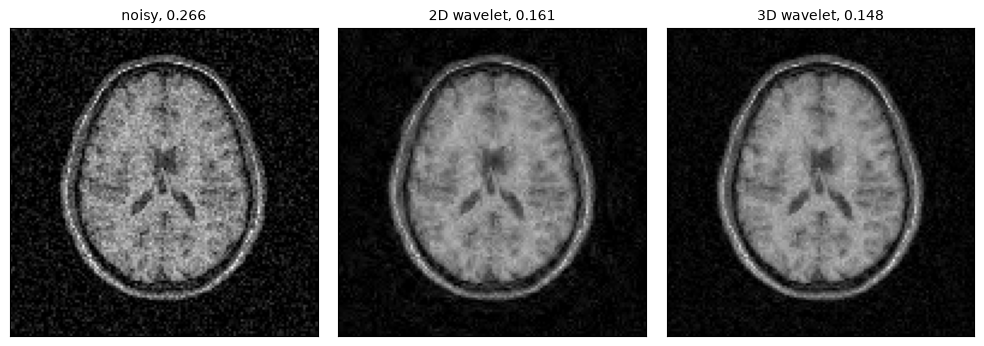

In [6]:
import matplotlib.pyplot as plt

figure, axes = plt.subplots(1, 3, figsize=(10, 3.4))
top = float(truth[8].max())
for axis, (image, title) in zip(
    axes,
    (
        (noisy[8], f"noisy, {error(noisy):.3f}"),
        (per_slice[8], f"2D wavelet, {error(per_slice):.3f}"),
        (volumetric[8], f"3D wavelet, {error(volumetric):.3f}"),
    ),
    strict=True,
):
    axis.imshow(image, cmap="gray", vmin=0, vmax=top)
    axis.set_title(title, fontsize=10)
    axis.set_xticks([])
    axis.set_yticks([])
figure.tight_layout()